In [1]:
import pandas as pd

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
res_df = pd.read_csv("Day_10_DEG_df.csv")

In [4]:
res_df

,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,WASH7P,435.021784,0.063040,0.177744,0.354667,0.722839,0.948424
1,nan ENSG00000241860,207.690701,-0.204948,0.268906,-0.762156,0.445967,0.858362
2,CICP27,32.186670,-0.457597,0.424983,-1.076741,0.281596,0.759498
3,nan ENSG00000308579,94.246903,-0.790661,0.315992,-2.502156,0.012344,0.238582
4,nan ENSG00000268903,608.638480,-0.503366,0.322131,-1.562613,0.118144,0.581442
...,...,...,...,...,...,...,...
17809,ND4,272422.517216,0.205953,0.241587,0.852501,0.393936,0.832502
17810,ND5,86790.014663,0.222051,0.196828,1.128145,0.259259,0.744215
17811,ND6,17494.037394,0.227004,0.202284,1.122201,0.261777,0.745530
17812,CYTB,68856.451456,0.313296,0.276981,1.131109,0.258009,0.744095


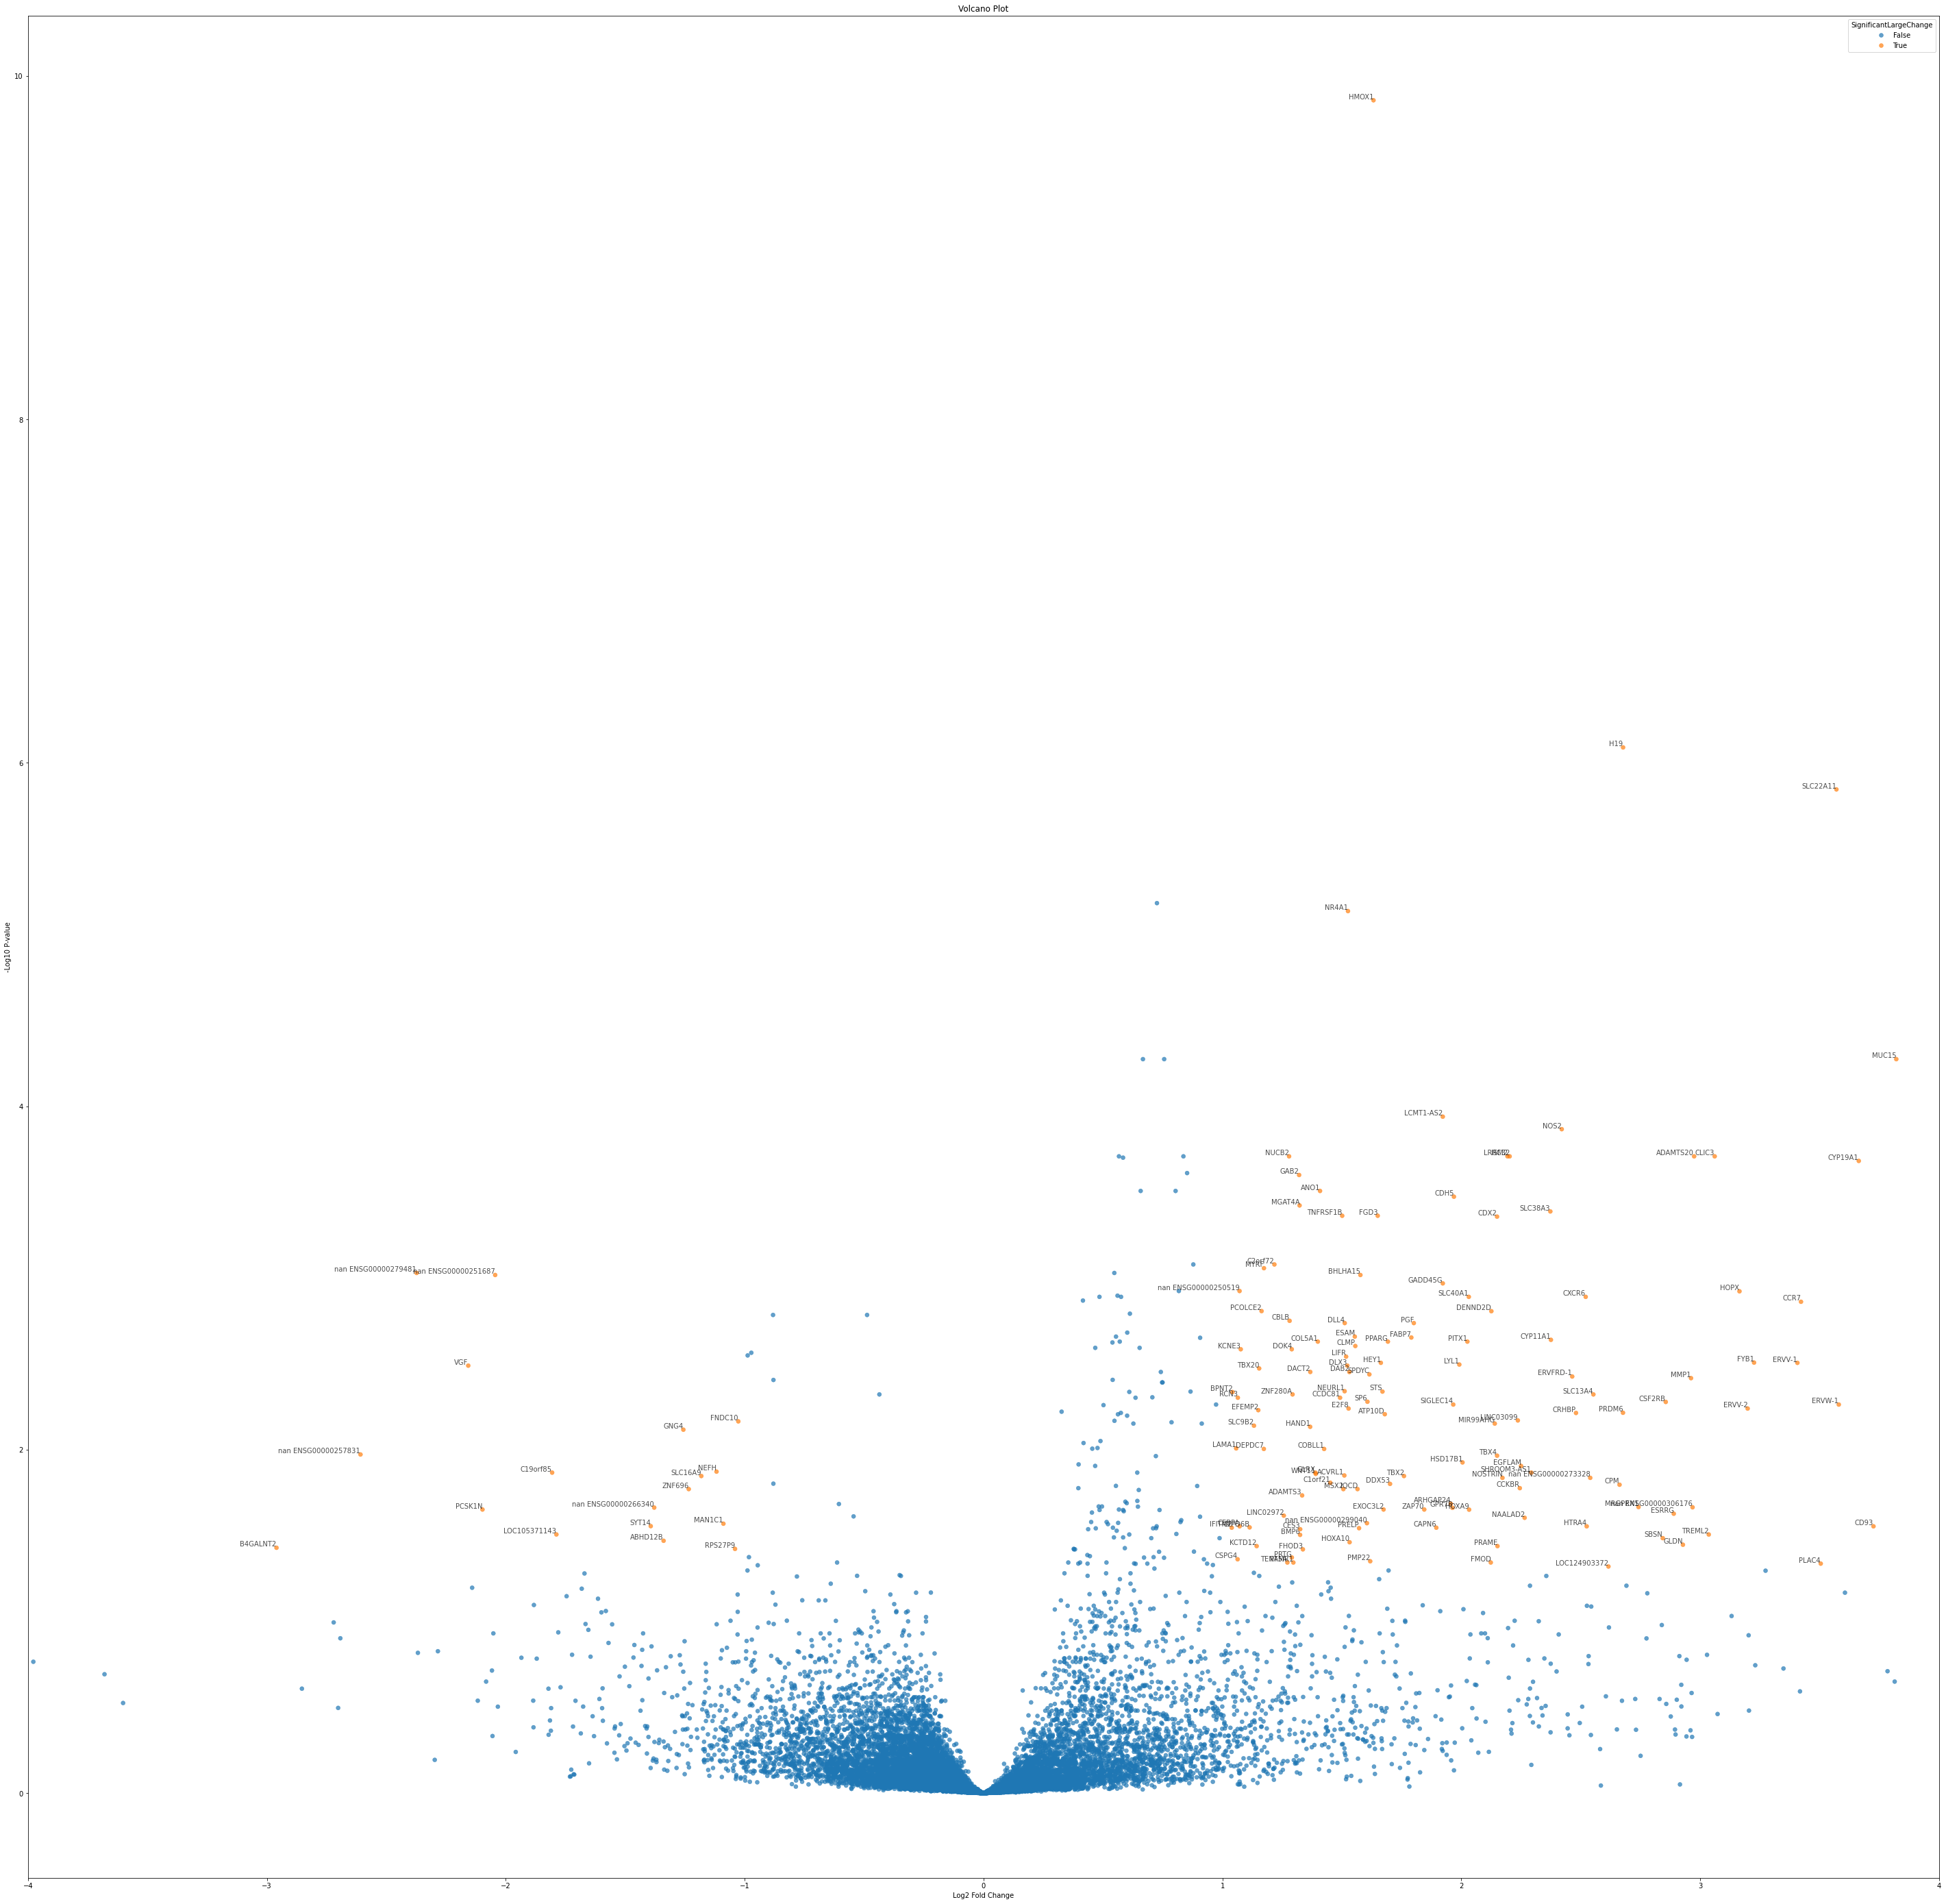

In [6]:
#Plot a large volcano plot to show all the details
res_df['significant'] = res_df['padj'] < 0.05
res_df['TwoFoldChange'] = (res_df['log2FoldChange'] >= 1) | (res_df['log2FoldChange'] <= -1)
res_df['SignificantLargeChange'] = (res_df['significant'] == True) & (res_df['TwoFoldChange'] == True)

# Volcano plot
plt.figure(figsize=(50,50))
sns.scatterplot(data=res_df, x='log2FoldChange', y=-np.log10(res_df['padj']),
                hue='SignificantLargeChange', edgecolor=None, alpha=0.7)
plt.xlim(-4, 4)
plt.title('Volcano Plot')
plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10 P-value')

for _, row in res_df[res_df['SignificantLargeChange']].iterrows():
    
    plt.text(row['log2FoldChange'], -np.log10(row['padj']), row['GeneID'], 
             ha='right', va='bottom', fontsize=10, alpha = 0.7)


plt.show()

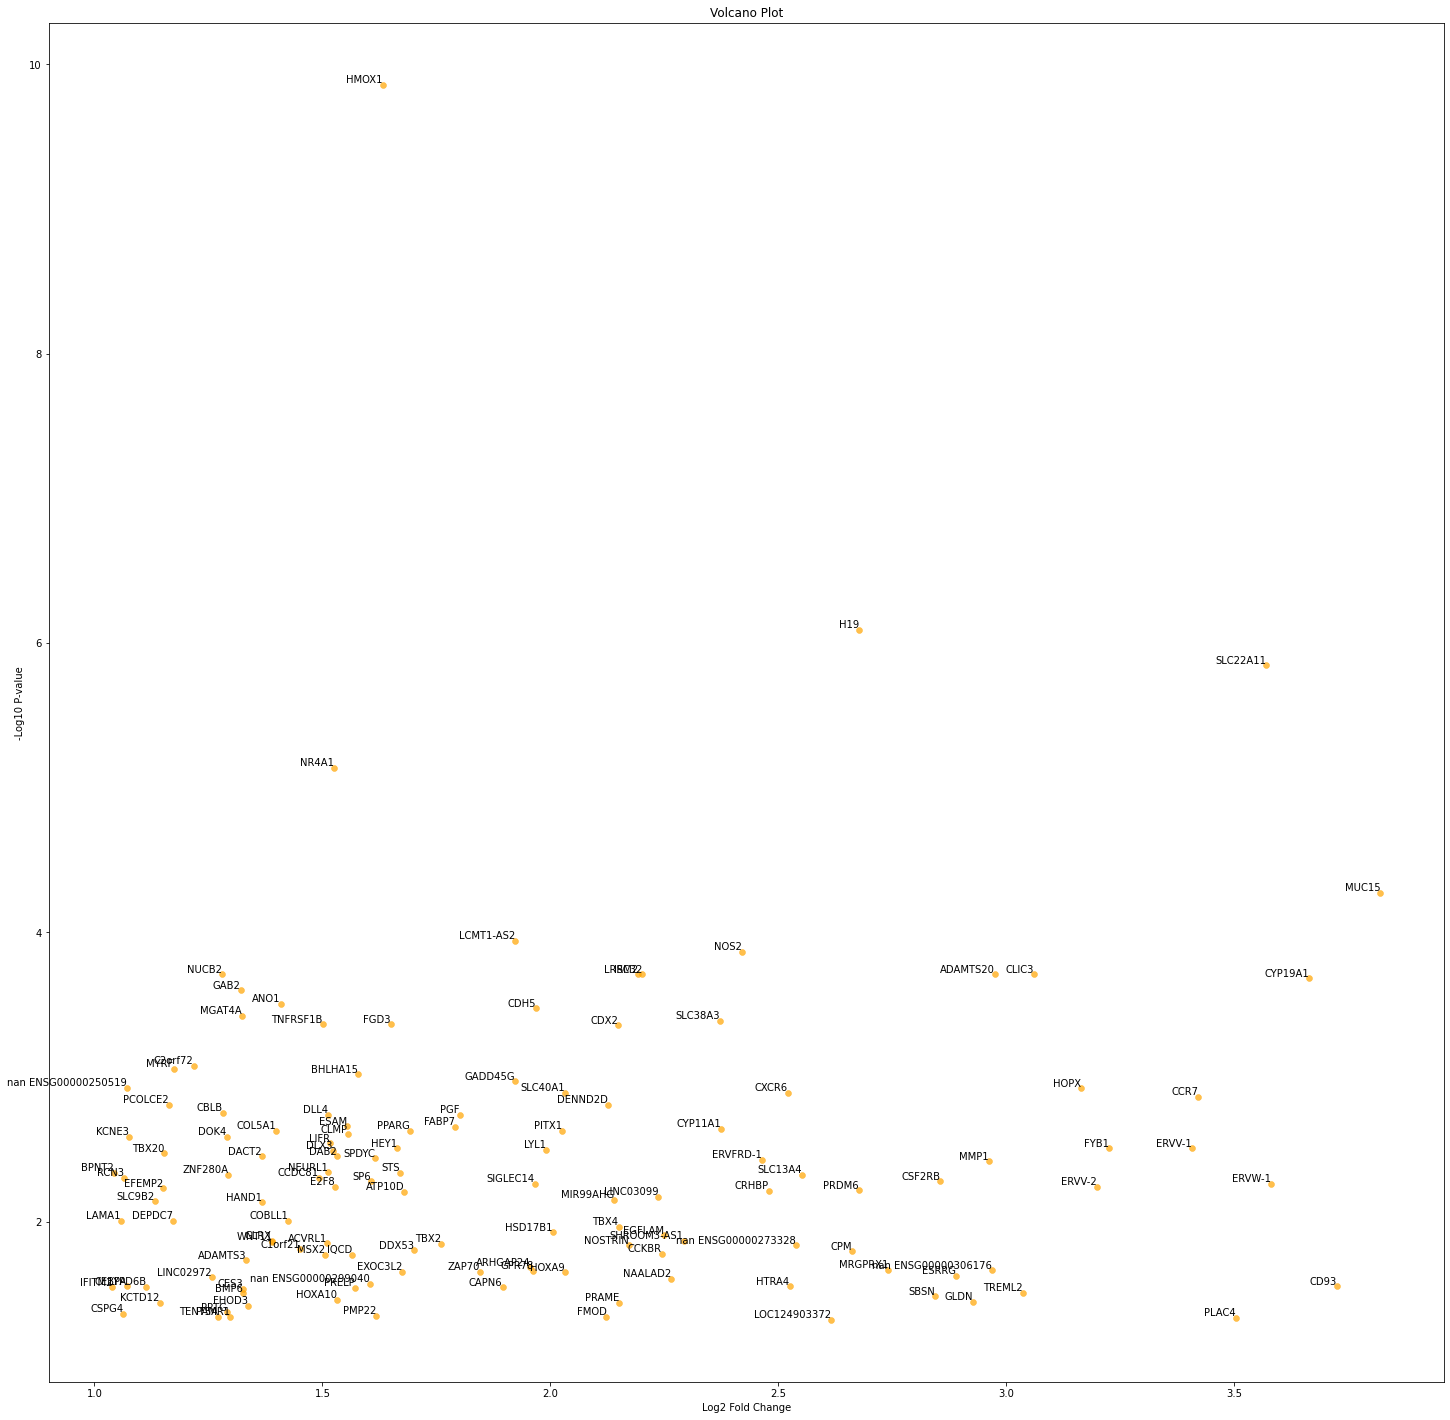

In [8]:
# Plot a only upregulated genes
res_df['significant'] = res_df['padj'] < 0.05
res_df['TwoFoldUpregulation'] = (res_df['log2FoldChange'] >= 1)
res_df['SignificantUpregulation'] = (res_df['significant'] == True) & (res_df['TwoFoldUpregulation'] == True)

res_df_SignificantUpregulation = res_df[res_df['SignificantUpregulation'] == True]

# Volcano plot
plt.figure(figsize=(25,25))
sns.scatterplot(data=res_df_SignificantUpregulation, x='log2FoldChange', y=-np.log10(res_df['padj']), edgecolor=None, alpha=0.7, color = 'orange')
#plt.xlim(-4, 4)
plt.title('Volcano Plot')
plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10 P-value')

for _, row in res_df[res_df['SignificantUpregulation']].iterrows():
    
    plt.text(row['log2FoldChange'], -np.log10(row['padj']), row['GeneID'], 
             ha='right', va='bottom', fontsize=10, alpha = 1)


plt.show()

In [9]:
res_df_SignificantUpregulation

,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant,TwoFoldChange,SignificantLargeChange,TwoFoldUpregulation,SignificantUpregulation
174,TNFRSF1B,1064.827356,1.501202,0.302480,4.962974,6.942204e-07,0.000434,True,True,True,True,True
936,DENND2D,39.482395,2.125652,0.462862,4.592410,4.381556e-06,0.001560,True,True,True,True,True
1445,C1orf21,170.445929,1.451427,0.380488,3.814646,1.363784e-04,0.015562,True,True,True,True,True
1516,FMOD,47.871138,2.123200,0.623431,3.405670,6.600180e-04,0.045363,True,True,True,True,True
1517,PRELP,136.942580,1.571792,0.439096,3.579607,3.441112e-04,0.028624,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
16916,CSF2RB,37.848867,2.855700,0.685920,4.163315,3.136597e-05,0.005267,True,True,True,True,True
17135,STS,954.151446,1.669743,0.395530,4.221531,2.426488e-05,0.004584,True,True,True,True,True
17213,DDX53,157.418824,1.701487,0.446861,3.807644,1.402968e-04,0.015806,True,True,True,True,True
17254,LINC03099,20.952392,2.236571,0.548759,4.075688,4.587853e-05,0.006749,True,True,True,True,True


In [19]:
Trophectoderm_related_genes = ['MUC15', 'ERVW-1', 'PLAC4', 'ERVV-1', 'HOPX', 'ERVV-2', 'H19', 'HTRA4',
                               'ERVFRD-1', 'CYP11A1', 'CDX2', 'HSD17B1', 'CAPN6', 'PGF', 'PPARG', 'STS', 
                               'HMOX1', 'COL5A1', 'HAND1', 'CEBPA', 'LAMA1']
Primitive_Endoderm_related_genes = ['SLC40A1', 'DAB2', 'LIFR', 'BMP6', 'GAB2']

In [20]:
res_df_SignificantUpregulation['Trophectoderm_related'] = res_df_SignificantUpregulation['GeneID'].isin(Trophectoderm_related_genes)
res_df_SignificantUpregulation['Primitive_Endoderm_related'] = res_df_SignificantUpregulation['GeneID'].isin(Primitive_Endoderm_related_genes)

C:\Users\huangq\AppData\Local\Temp/ipykernel_29944/2452237139.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_df_SignificantUpregulation['Trophectoderm_related'] = res_df_SignificantUpregulation['GeneID'].isin(Trophectoderm_related_genes)
C:\Users\huangq\AppData\Local\Temp/ipykernel_29944/2452237139.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_df_SignificantUpregulation['Primitive_Endoderm_related'] = res_df_SignificantUpregulation['GeneID'].isin(Primitive_Endoderm_related_genes)


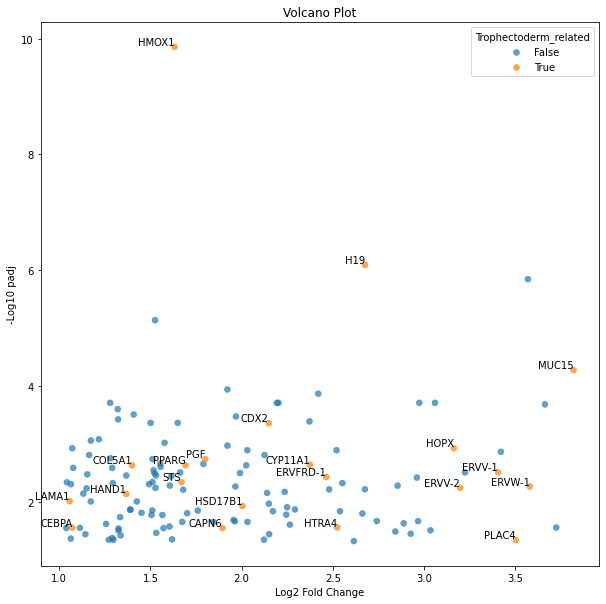

In [32]:
# Volcano plot
plt.figure(figsize=(10,10))
sns.scatterplot(data=res_df_SignificantUpregulation, x='log2FoldChange', y=-np.log10(res_df['padj']), edgecolor=None, alpha=0.7, color = 'orange', hue = 'Trophectoderm_related')
#plt.xlim(-4, 4)
plt.title('Volcano Plot')
plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10 padj')

for _, row in res_df[res_df['SignificantUpregulation']].iterrows():
    if row['GeneID'] in Trophectoderm_related_genes:
        plt.text(row['log2FoldChange'], -np.log10(row['padj']), row['GeneID'], 
                 ha='right', va='bottom', fontsize=10, alpha = 1)

plt.show()

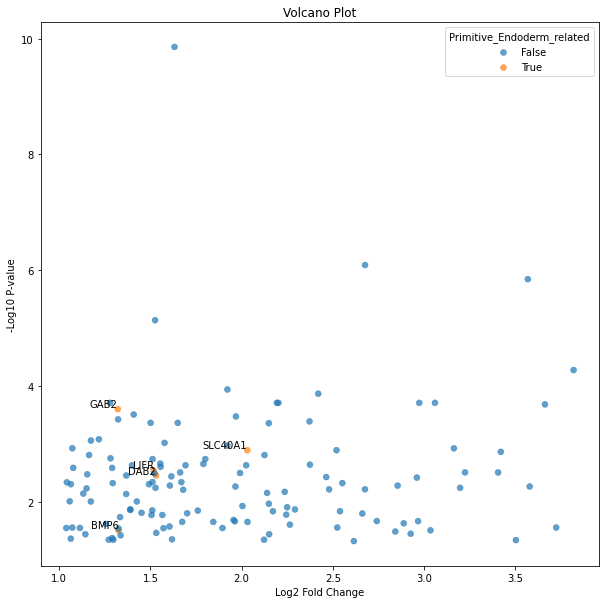

In [27]:
# Volcano plot
plt.figure(figsize=(10,10))
sns.scatterplot(data=res_df_SignificantUpregulation, x='log2FoldChange', y=-np.log10(res_df['padj']), edgecolor=None, alpha=0.7, color = 'orange', hue = 'Primitive_Endoderm_related')
#plt.xlim(-4, 4)
plt.title('Volcano Plot')
plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10 P-value')

for _, row in res_df[res_df['SignificantUpregulation']].iterrows():
    if row['GeneID'] in Primitive_Endoderm_related_genes:
        plt.text(row['log2FoldChange'], -np.log10(row['padj']), row['GeneID'], 
                 ha='right', va='bottom', fontsize=10, alpha = 1)

plt.show()

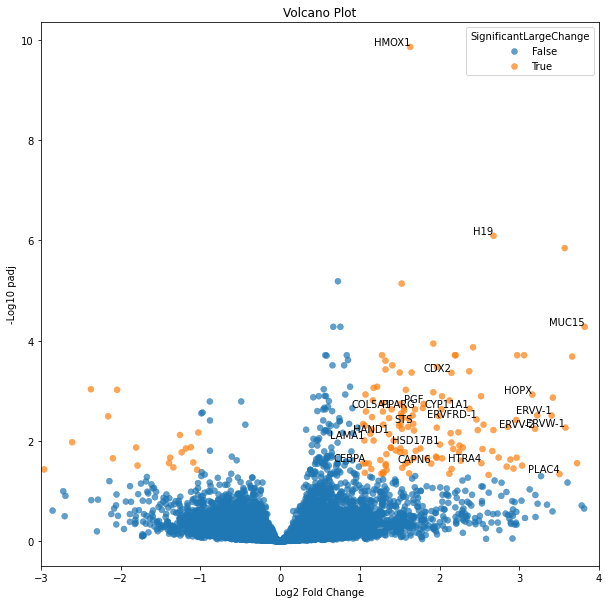

In [35]:
# Volcano plot
plt.figure(figsize=(10,10))
sns.scatterplot(data=res_df, x='log2FoldChange', y=-np.log10(res_df['padj']),
                hue='SignificantLargeChange', edgecolor=None, alpha=0.7)
plt.xlim(-3, 4)
plt.title('Volcano Plot')
plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10 padj')

for _, row in res_df[res_df['SignificantUpregulation']].iterrows():
    if row['GeneID'] in Trophectoderm_related_genes:
        plt.text(row['log2FoldChange'], -np.log10(row['padj']), row['GeneID'], 
                 ha='right', va='bottom', fontsize=10, alpha = 1)

plt.savefig('/Bioinformatics_D/Figures/Volcano_small_day10_highlight_R2.pdf', bbox_inches='tight', dpi=300)
plt.savefig('/Bioinformatics_D/Figures/Volcano_small_day10_highlight_R2.png', bbox_inches='tight', dpi=300)
plt.show()

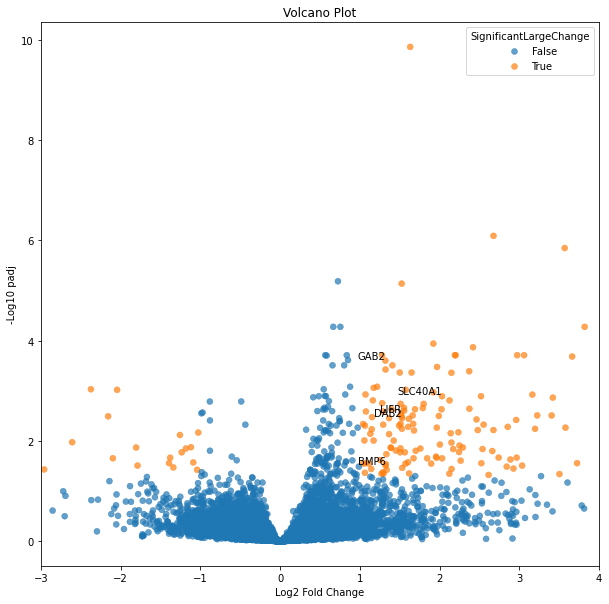

In [36]:
# Volcano plot
plt.figure(figsize=(10,10))
sns.scatterplot(data=res_df, x='log2FoldChange', y=-np.log10(res_df['padj']),
                hue='SignificantLargeChange', edgecolor=None, alpha=0.7)
plt.xlim(-3, 4)
plt.title('Volcano Plot')
plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10 padj')

for _, row in res_df[res_df['SignificantUpregulation']].iterrows():
    if row['GeneID'] in Primitive_Endoderm_related_genes:
        plt.text(row['log2FoldChange'], -np.log10(row['padj']), row['GeneID'], 
                 ha='right', va='bottom', fontsize=10, alpha = 1)

plt.savefig('/Bioinformatics_D/Figures/Volcano_small_day10_highlight2_R2.pdf', bbox_inches='tight', dpi=300)
plt.savefig('/Bioinformatics_D/Figures/Volcano_small_day10_highlight2_R2.png', bbox_inches='tight', dpi=300)
plt.show()